In [ ]:
# Exploratory Data Analysis

## E-Commerce Order Analytics

This notebook explores customer behavior, product performance, revenue trends, order statuses, payment methods, coupon usage, and referral-source performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(
    "../data/processed/ecommerce_cleaned.csv"
)

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,ReferralSource,TotalPrice,Year,Month,MonthName,DayOfWeek,DayOfMonth,CustomerOrderCount,CustomerType,UsedCoupon
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,...,Instagram,2853.10,2023,1,January,Wednesday,4,1,One-Time Customer,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,...,Referral,302.70,2024,8,August,Friday,23,1,One-Time Customer,1
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,...,Email,2753.40,2024,2,February,Tuesday,27,1,One-Time Customer,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,...,Facebook,273.19,2023,10,October,Sunday,15,1,One-Time Customer,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,...,Email,2504.04,2025,5,May,Thursday,8,1,One-Time Customer,1


In [3]:
df.shape

(1200, 22)

In [4]:
product_revenue = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

Product
Printer    195585.6750
Chair      195565.6175
Laptop     192044.1750
Tablet     186403.1650
Monitor    175590.8675
Desk       167459.9300
Phone      151722.3900
Name: TotalPrice, dtype: float64

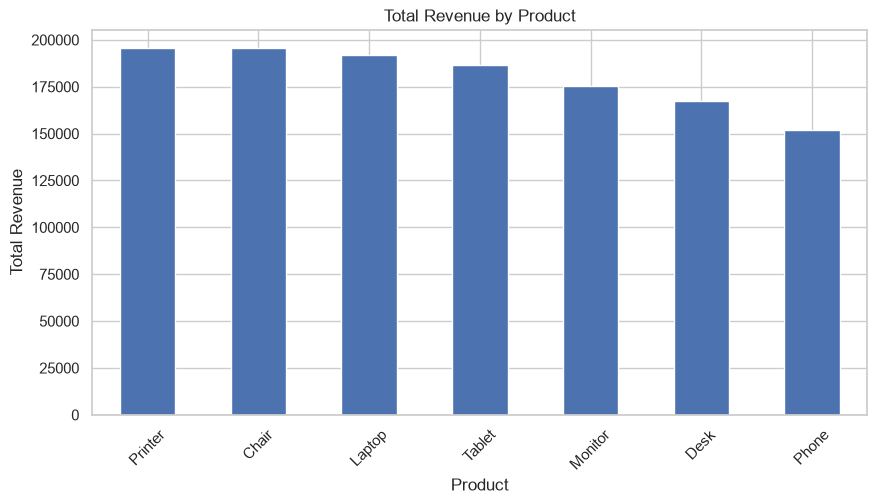

In [5]:
plt.figure(figsize=(10, 5))

product_revenue.plot(kind="bar")

plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.show()

In [6]:
product_orders = (
    df["Product"]
    .value_counts()
)

product_orders

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

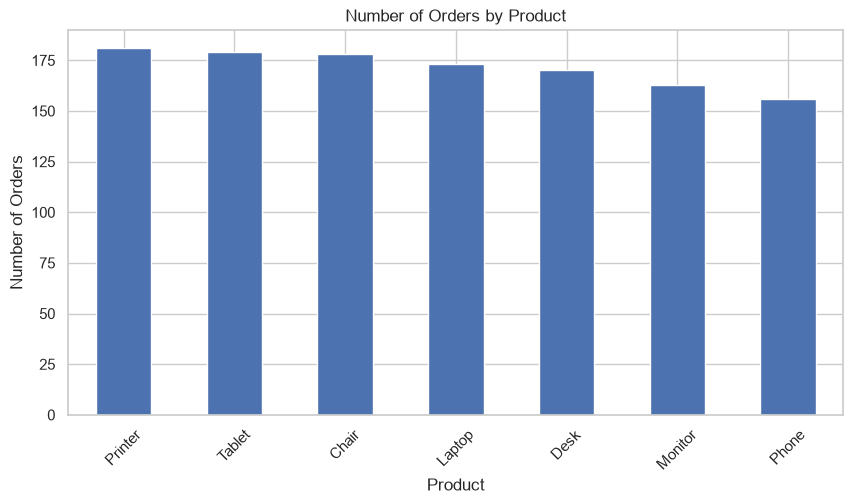

In [7]:
plt.figure(figsize=(10, 5))

product_orders.plot(kind="bar")

plt.title("Number of Orders by Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

In [8]:
average_order_value = (
    df.groupby("Product")["TotalPrice"]
    .mean()
    .sort_values(ascending=False)
)

average_order_value

Product
Laptop     1110.081936
Chair      1098.683244
Printer    1080.583840
Monitor    1077.244586
Tablet     1041.358464
Desk        985.058412
Phone       972.579423
Name: TotalPrice, dtype: float64

In [9]:
order_status_counts = (
    df["OrderStatus"]
    .value_counts()
)

order_status_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

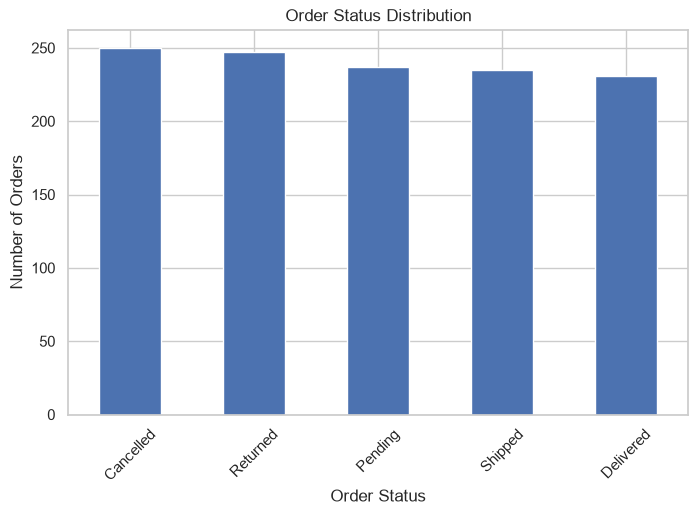

In [10]:
plt.figure(figsize=(8, 5))

order_status_counts.plot(
    kind="bar"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

In [11]:
cancellation_rate = (
    df["OrderStatus"].eq("Cancelled").mean() * 100
)

print(
    f"Cancellation Rate: {cancellation_rate:.2f}%"
)

Cancellation Rate: 20.83%


In [12]:
return_rate = (
    df["OrderStatus"].eq("Returned").mean() * 100
)

print(
    f"Return Rate: {return_rate:.2f}%"
)

Return Rate: 20.58%


In [13]:
payment_counts = (
    df["PaymentMethod"]
    .value_counts()
)

payment_counts

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

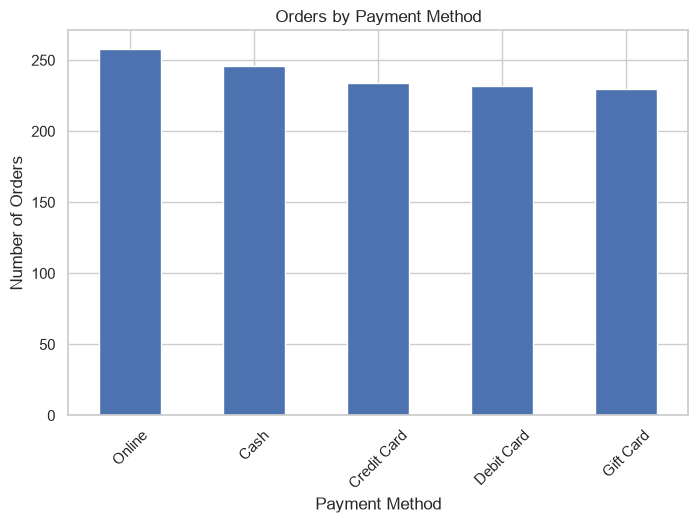

In [14]:
plt.figure(figsize=(8, 5))

payment_counts.plot(
    kind="bar"
)

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

In [15]:
payment_revenue = (
    df.groupby("PaymentMethod")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

PaymentMethod
Credit Card    263847.6300
Online         262216.6125
Cash           259731.7975
Gift Card      246218.1925
Debit Card     232357.5875
Name: TotalPrice, dtype: float64

In [16]:
referral_analysis = (
    df.groupby("ReferralSource")
    .agg(
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
)

referral_analysis

,Orders,Revenue,AverageOrderValue
ReferralSource,,,
Instagram,259,275262.1075,1062.788060
Email,250,261682.5575,1046.730230
Google,241,250401.6875,1039.011151
Facebook,228,250213.4800,1097.427544
Referral,222,226811.9875,1021.675619


In [17]:
coupon_analysis = (
    df.groupby("CouponCode")
    .agg(
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
)

coupon_analysis

,Orders,Revenue,AverageOrderValue
CouponCode,,,
FREESHIP,313,335013.6475,1070.331142
NO_COUPON,309,322286.3750,1042.997977
SAVE10,286,304648.6500,1065.205070
WINTER15,292,302423.1475,1035.695711


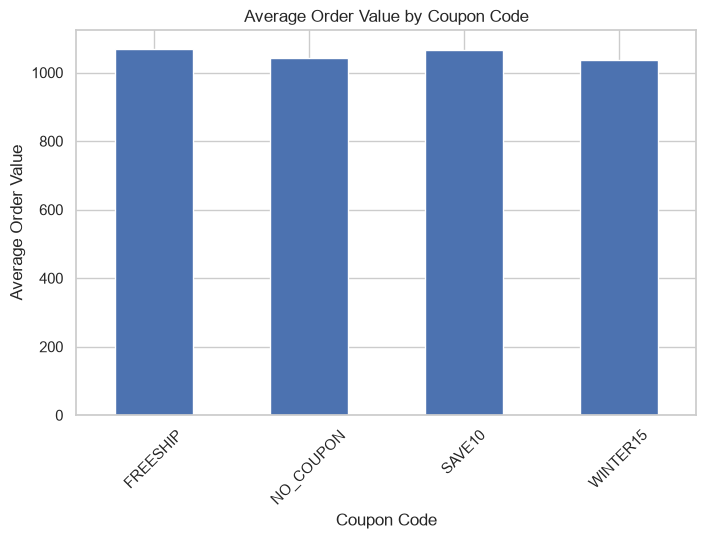

In [18]:
plt.figure(figsize=(8, 5))

coupon_analysis["AverageOrderValue"].plot(
    kind="bar"
)

plt.title("Average Order Value by Coupon Code")
plt.xlabel("Coupon Code")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)
plt.show()

In [19]:
customer_type_analysis = (
    df.groupby("CustomerType")
    .agg(
        Customers=("CustomerID", "nunique"),
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
)

customer_type_analysis

,Customers,Orders,Revenue,AverageOrderValue
CustomerType,,,,
One-Time Customer,1178,1178,1.244897e+06,1056.788270
Repeat Customer,11,22,1.947524e+04,885.238068


In [20]:
monthly_revenue = (
    df.groupby(
        ["Year", "Month"]
    )["TotalPrice"]
    .sum()
)

monthly_revenue

Year  Month
2023  1        56685.7500
      2        40077.8675
      3        48586.0275
      4        27751.7100
      5        63776.4475
      6        49439.6475
      7        42820.6600
      8        54226.1475
      9        29526.6700
      10       52604.2575
      11       43025.1775
      12       43754.7300
2024  1        38528.0800
      2        36909.5700
      3        36030.9000
      4        49613.1400
      5        27909.1100
      6        68068.5400
      7        42941.9875
      8        31991.0700
      9        39794.9800
      10       37226.9700
      11       32413.7600
      12       38785.7700
2025  1        29099.4000
      2        35317.5500
      3        39200.6600
      4        31821.2000
      5        43396.6400
      6        53047.4000
Name: TotalPrice, dtype: float64

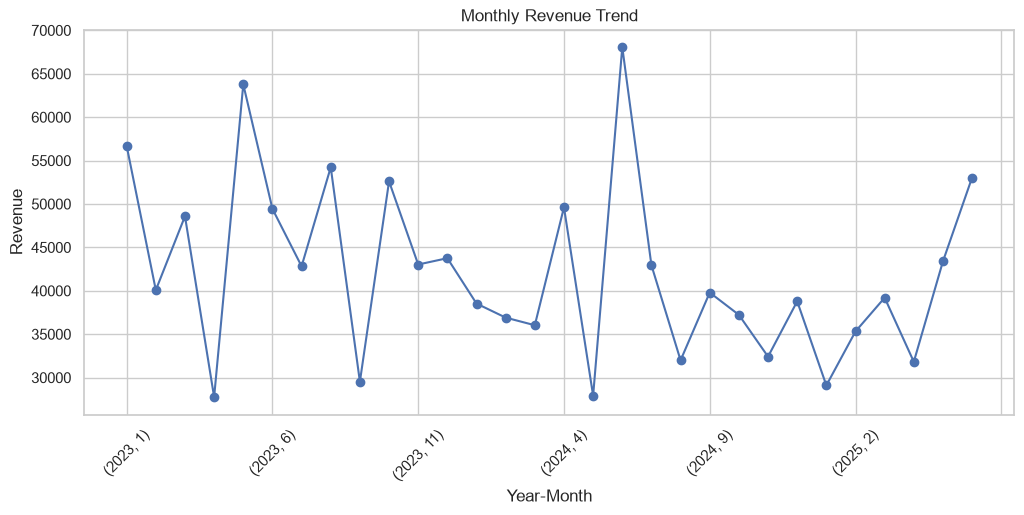

In [21]:
plt.figure(figsize=(12, 5))

monthly_revenue.plot(
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

In [22]:
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "CustomerOrderCount"
]

In [23]:
correlation_matrix = (
    df[numeric_columns]
    .corr()
)

correlation_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CustomerOrderCount
Quantity,1.000000,0.014553,0.650061,0.615362,-0.021229
UnitPrice,0.014553,1.000000,0.000602,0.717232,-0.026779
ItemsInCart,0.650061,0.000602,1.000000,0.392579,-0.026334
TotalPrice,0.615362,0.717232,0.392579,1.000000,-0.028114
CustomerOrderCount,-0.021229,-0.026779,-0.026334,-0.028114,1.000000


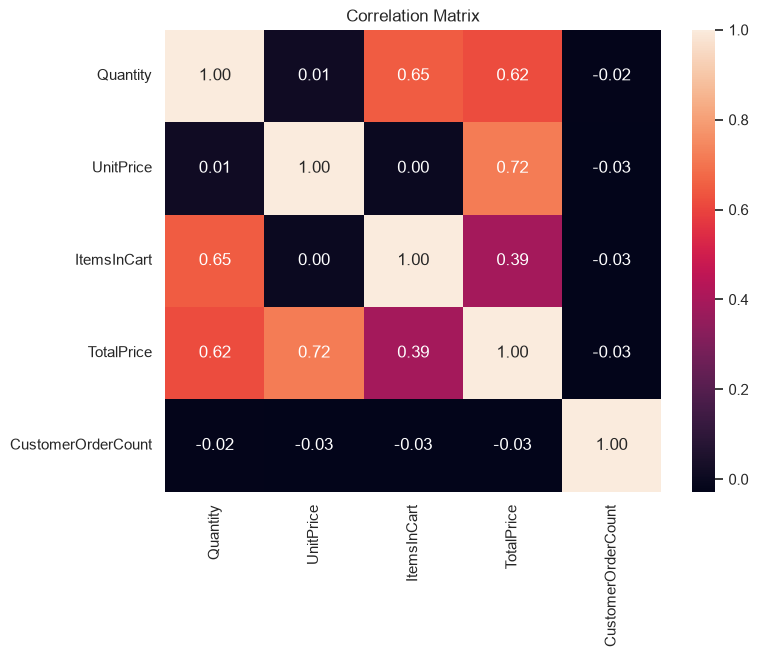

In [24]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()